# YOLO26s Training Pipeline

## 1. Setup & Configuration

In [7]:
import torch
from pathlib import Path
from ultralytics import YOLO

# Device detection
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
print(f"Using device:    {DEVICE}")

PyTorch version: 2.11.0+cu126
CUDA available:  True
GPU:             NVIDIA GeForce RTX 3060
Using device:    cuda


In [8]:
# Paths — absolute to avoid CWD issues
BASE_DIR = Path(r"D:/school/school/Final Project/ENG402 Graduation Project/model_building")
DATASET_DIR = BASE_DIR / "datasets" / "dataset1" / "data"
DATASET_YAML = DATASET_DIR / "dataset.yaml"

# ======================================================================
# Training hyperparameters
# ======================================================================

# --- Model & project ---
MODEL_NAME = "yolo26s.pt"
PROJECT = str(BASE_DIR / "model_train" / "runs")
EXPERIMENT = "yolo26s_shapes"

# --- Training control ---
EPOCHS = 50
BATCH_SIZE = 32
IMG_SIZE = 640
PATIENCE = 20  # early stopping patience
SEED = 42
DETERMINISTIC = True
AMP = True
WORKERS = 0
FRACTION = 1.0

# --- Learning rate schedule ---
LR0 = 0.01
LRF = 0.1
WARMUP_EPOCHS = 3
WARMUP_BIAS_LR = 0.1
WARMUP_MOMENTUM = 0.8

# --- Loss weights ---
BOX = 7.5
CLS = 0.5
DFL = 1.5  # distribution focal loss (YOLOv8+ replaces obj)

# --- Regularization ---
WEIGHT_DECAY = 0.01
DROPOUT = 0.2

# --- Segmentation masks ---
OVERLAP_MASK = True
MASK_RATIO = 4

# --- Augmentation ---
FLIPLR = 0.5
FLIPUD = 0.0
DEGREES = 10.0
SCALE = 0.5
TRANSLATE = 0.1
SHEAR = 2.0
PERSPECTIVE = 0.0005
HSV_H = 0.01
HSV_S = 0.7
HSV_V = 0.4
MOSAIC = 1.0
MIXUP = 0.1
COPY_PASTE = 0.2
AUTO_AUGMENT = 'autoaugment'

# ======================================================================
# Configuration summary
# ======================================================================
print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
print(f"Dataset:       {DATASET_YAML}")
print(f"Model:         {MODEL_NAME}")
print(f"Experiment:    {EXPERIMENT}")
print(f"Device:        {DEVICE}")

print("\n--- Training control ---")
print(f"Epochs:        {EPOCHS}")
print(f"Batch size:    {BATCH_SIZE}")
print(f"Image size:    {IMG_SIZE}")
print(f"Patience:      {PATIENCE}")
print(f"Seed:          {SEED}  (deterministic={DETERMINISTIC})")
print(f"AMP:           {AMP}")
print(f"Workers:       {WORKERS}")
print(f"Fraction:      {FRACTION}")

print("\n--- LR schedule ---")
print(f"lr0 / lrf:     {LR0} / {LRF}")
print(f"Warmup:        {WARMUP_EPOCHS} epochs (bias_lr={WARMUP_BIAS_LR}, momentum={WARMUP_MOMENTUM})")

print("\n--- Loss weights ---")
print(f"box/cls/dfl:   {BOX} / {CLS} / {DFL}")

print("\n--- Regularization ---")
print(f"weight_decay:  {WEIGHT_DECAY}")
print(f"dropout:       {DROPOUT}")

print("\n--- Augmentation ---")
print(f"flip (lr/ud):  {FLIPLR} / {FLIPUD}")
print(f"degrees:       {DEGREES}")
print(f"scale:         {SCALE}")
print(f"translate:     {TRANSLATE}")
print(f"shear:         {SHEAR}")
print(f"perspective:   {PERSPECTIVE}")
print(f"hsv (h/s/v):   {HSV_H} / {HSV_S} / {HSV_V}")
print(f"mosaic:        {MOSAIC}")
print(f"mixup:         {MIXUP}")
print(f"copy_paste:    {COPY_PASTE}")
print(f"auto_augment:  {AUTO_AUGMENT}")
print("=" * 60)

CONFIGURATION
Dataset:       D:\school\school\Final Project\ENG402 Graduation Project\model_building\datasets\dataset1\data\dataset.yaml
Model:         yolo26s.pt
Experiment:    yolo26s_shapes
Device:        cuda

--- Training control ---
Epochs:        50
Batch size:    32
Image size:    640
Patience:      20
Seed:          42  (deterministic=True)
AMP:           True
Workers:       0
Fraction:      1.0

--- LR schedule ---
lr0 / lrf:     0.01 / 0.1
Warmup:        3 epochs (bias_lr=0.1, momentum=0.8)

--- Loss weights ---
box/cls/dfl:   7.5 / 0.5 / 1.5

--- Regularization ---
weight_decay:  0.01
dropout:       0.2

--- Augmentation ---
flip (lr/ud):  0.5 / 0.0
degrees:       10.0
scale:         0.5
translate:     0.1
shear:         2.0
perspective:   0.0005
hsv (h/s/v):   0.01 / 0.7 / 0.4
mosaic:        1.0
mixup:         0.1
copy_paste:    0.2
auto_augment:  autoaugment


## 2. Dataset Verification

In [9]:
import yaml

# Verify dataset.yaml exists and print contents
assert DATASET_YAML.exists(), f"dataset.yaml not found at {DATASET_YAML}"

with open(DATASET_YAML) as f:
    ds_config = yaml.safe_load(f)

print("dataset.yaml contents:")
for k, v in ds_config.items():
    print(f"  {k}: {v}")

# Count samples per split
for split in ["train", "val", "test"]:
    img_dir = DATASET_DIR / ds_config[split]
    lbl_dir = DATASET_DIR / ds_config[split].replace("images", "labels")
    n_img = len(list(img_dir.glob("*"))) if img_dir.exists() else 0
    n_lbl = len(list(lbl_dir.glob("*.txt"))) if lbl_dir.exists() else 0
    print(f"\n{split}: {n_img} images, {n_lbl} labels")
    if n_img != n_lbl:
        print(f"  WARNING: mismatch ({n_img} images vs {n_lbl} labels)")

dataset.yaml contents:
  names: {0: 'circle', 1: 'hexagon', 2: 'rectangle', 3: 'star', 4: 'triangle'}
  nc: 5
  path: D:/school/school/Final Project/ENG402 Graduation Project/model_building/datasets/dataset1/data
  train: images/train
  val: images/val
  test: images/test

train: 366 images, 366 labels

val: 73 images, 73 labels

test: 50 images, 50 labels


## 3. Training

In [10]:
# Load pretrained YOLO26s
model = YOLO(MODEL_NAME)
print(f"Model loaded: {MODEL_NAME}")

Model loaded: yolo26s.pt


In [11]:
# Train
results = model.train(
    # --- Data & output ---
    data=str(DATASET_YAML),
    project=PROJECT,
    name=EXPERIMENT,
    exist_ok=True,

    # --- Training control ---
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE,
    patience=PATIENCE,
    device=DEVICE,
    seed=SEED,
    deterministic=DETERMINISTIC,
    amp=AMP,
    workers=WORKERS,
    fraction=FRACTION,
    pretrained=True,
    verbose=True,

    # --- LR schedule ---
    lr0=LR0,
    lrf=LRF,
    warmup_epochs=WARMUP_EPOCHS,
    warmup_bias_lr=WARMUP_BIAS_LR,
    warmup_momentum=WARMUP_MOMENTUM,

    # --- Loss weights ---
    box=BOX,
    cls=CLS,
    dfl=DFL,

    # --- Regularization ---
    weight_decay=WEIGHT_DECAY,
    dropout=DROPOUT,

    # --- Segmentation masks ---
    overlap_mask=OVERLAP_MASK,
    mask_ratio=MASK_RATIO,

    # --- Augmentation ---
    fliplr=FLIPLR,
    flipud=FLIPUD,
    degrees=DEGREES,
    scale=SCALE,
    translate=TRANSLATE,
    shear=SHEAR,
    perspective=PERSPECTIVE,
    hsv_h=HSV_H,
    hsv_s=HSV_S,
    hsv_v=HSV_V,
    mosaic=MOSAIC,
    mixup=MIXUP,
    copy_paste=COPY_PASTE,
    auto_augment=AUTO_AUGMENT,
)

Ultralytics 8.4.38  Python-3.12.10 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3060, 12287MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=autoaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\school\school\Final Project\ENG402 Graduation Project\model_building\datasets\dataset1\data\dataset.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.2, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26s_shapes,

## 4. Validation

In [12]:
# Load best weights from training
best_weights = Path(PROJECT) / EXPERIMENT / "weights" / "best.pt"
assert best_weights.exists(), f"Best weights not found at {best_weights}"

best_model = YOLO(str(best_weights))
print(f"Loaded best weights: {best_weights}")

Loaded best weights: D:\school\school\Final Project\ENG402 Graduation Project\model_building\model_train\runs\yolo26s_shapes\weights\best.pt


In [13]:
# Validate on val split
val_results = best_model.val(
    data=str(DATASET_YAML),
    split="val",
    device=DEVICE,
    verbose=True,
)

print(f"\n--- Validation Results ---")
print(f"mAP50:    {val_results.box.map50:.4f}")
print(f"mAP50-95: {val_results.box.map:.4f}")
print(f"Precision: {val_results.box.mp:.4f}")
print(f"Recall:    {val_results.box.mr:.4f}")

Ultralytics 8.4.38  Python-3.12.10 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3060, 12287MiB)
YOLO26s summary (fused): 122 layers, 9,467,115 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 202.9116.5 MB/s, size: 78.8 KB)
val: Scanning D:\school\school\Final Project\ENG402 Graduation Project\model_building\datasets\dataset1\data\labels\val.cache... 73 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 73/73  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.0s/it 10.2s.7s7
                   all         73         73       0.95      0.967       0.99      0.805
                circle         12         12      0.906          1      0.989      0.798
               hexagon         21         21      0.991          1      0.995      0.785
             rectangle          9          9      0.897      0.967      0.984      0.883
                  star         13         13      0.986  

## 5. Testing & Metrics

In [14]:
# Test on test split
test_results = best_model.val(
    data=str(DATASET_YAML),
    split="test",
    device=DEVICE,
    verbose=True,
)

print(f"\n--- Test Results ---")
print(f"mAP50:     {test_results.box.map50:.4f}")
print(f"mAP50-95:  {test_results.box.map:.4f}")
print(f"Precision: {test_results.box.mp:.4f}")
print(f"Recall:    {test_results.box.mr:.4f}")

Ultralytics 8.4.38  Python-3.12.10 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3060, 12287MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 6.21.9 MB/s, size: 89.5 KB)
val: Scanning D:\school\school\Final Project\ENG402 Graduation Project\model_building\datasets\dataset1\data\labels\test.cache... 50 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 50/50  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.3s/it 9.3s0.8s0
                   all         50         52      0.978      0.971      0.995      0.786
                circle         14         14          1      0.966      0.995      0.779
               hexagon         11         11      0.978          1      0.995      0.774
             rectangle          6          6      0.933          1      0.995      0.755
                  star         13         13      0.978          1      0.995      0.815
              triangle          8          8          1

In [15]:
# Per-class metrics
class_names = ds_config["names"]
print("\nPer-class AP50:")
for i, ap in enumerate(test_results.box.ap50):
    print(f"  {class_names[i]:>12s}: {ap:.4f}")


Per-class AP50:
        circle: 0.9950
       hexagon: 0.9950
     rectangle: 0.9950
          star: 0.9950
      triangle: 0.9950



results.png:


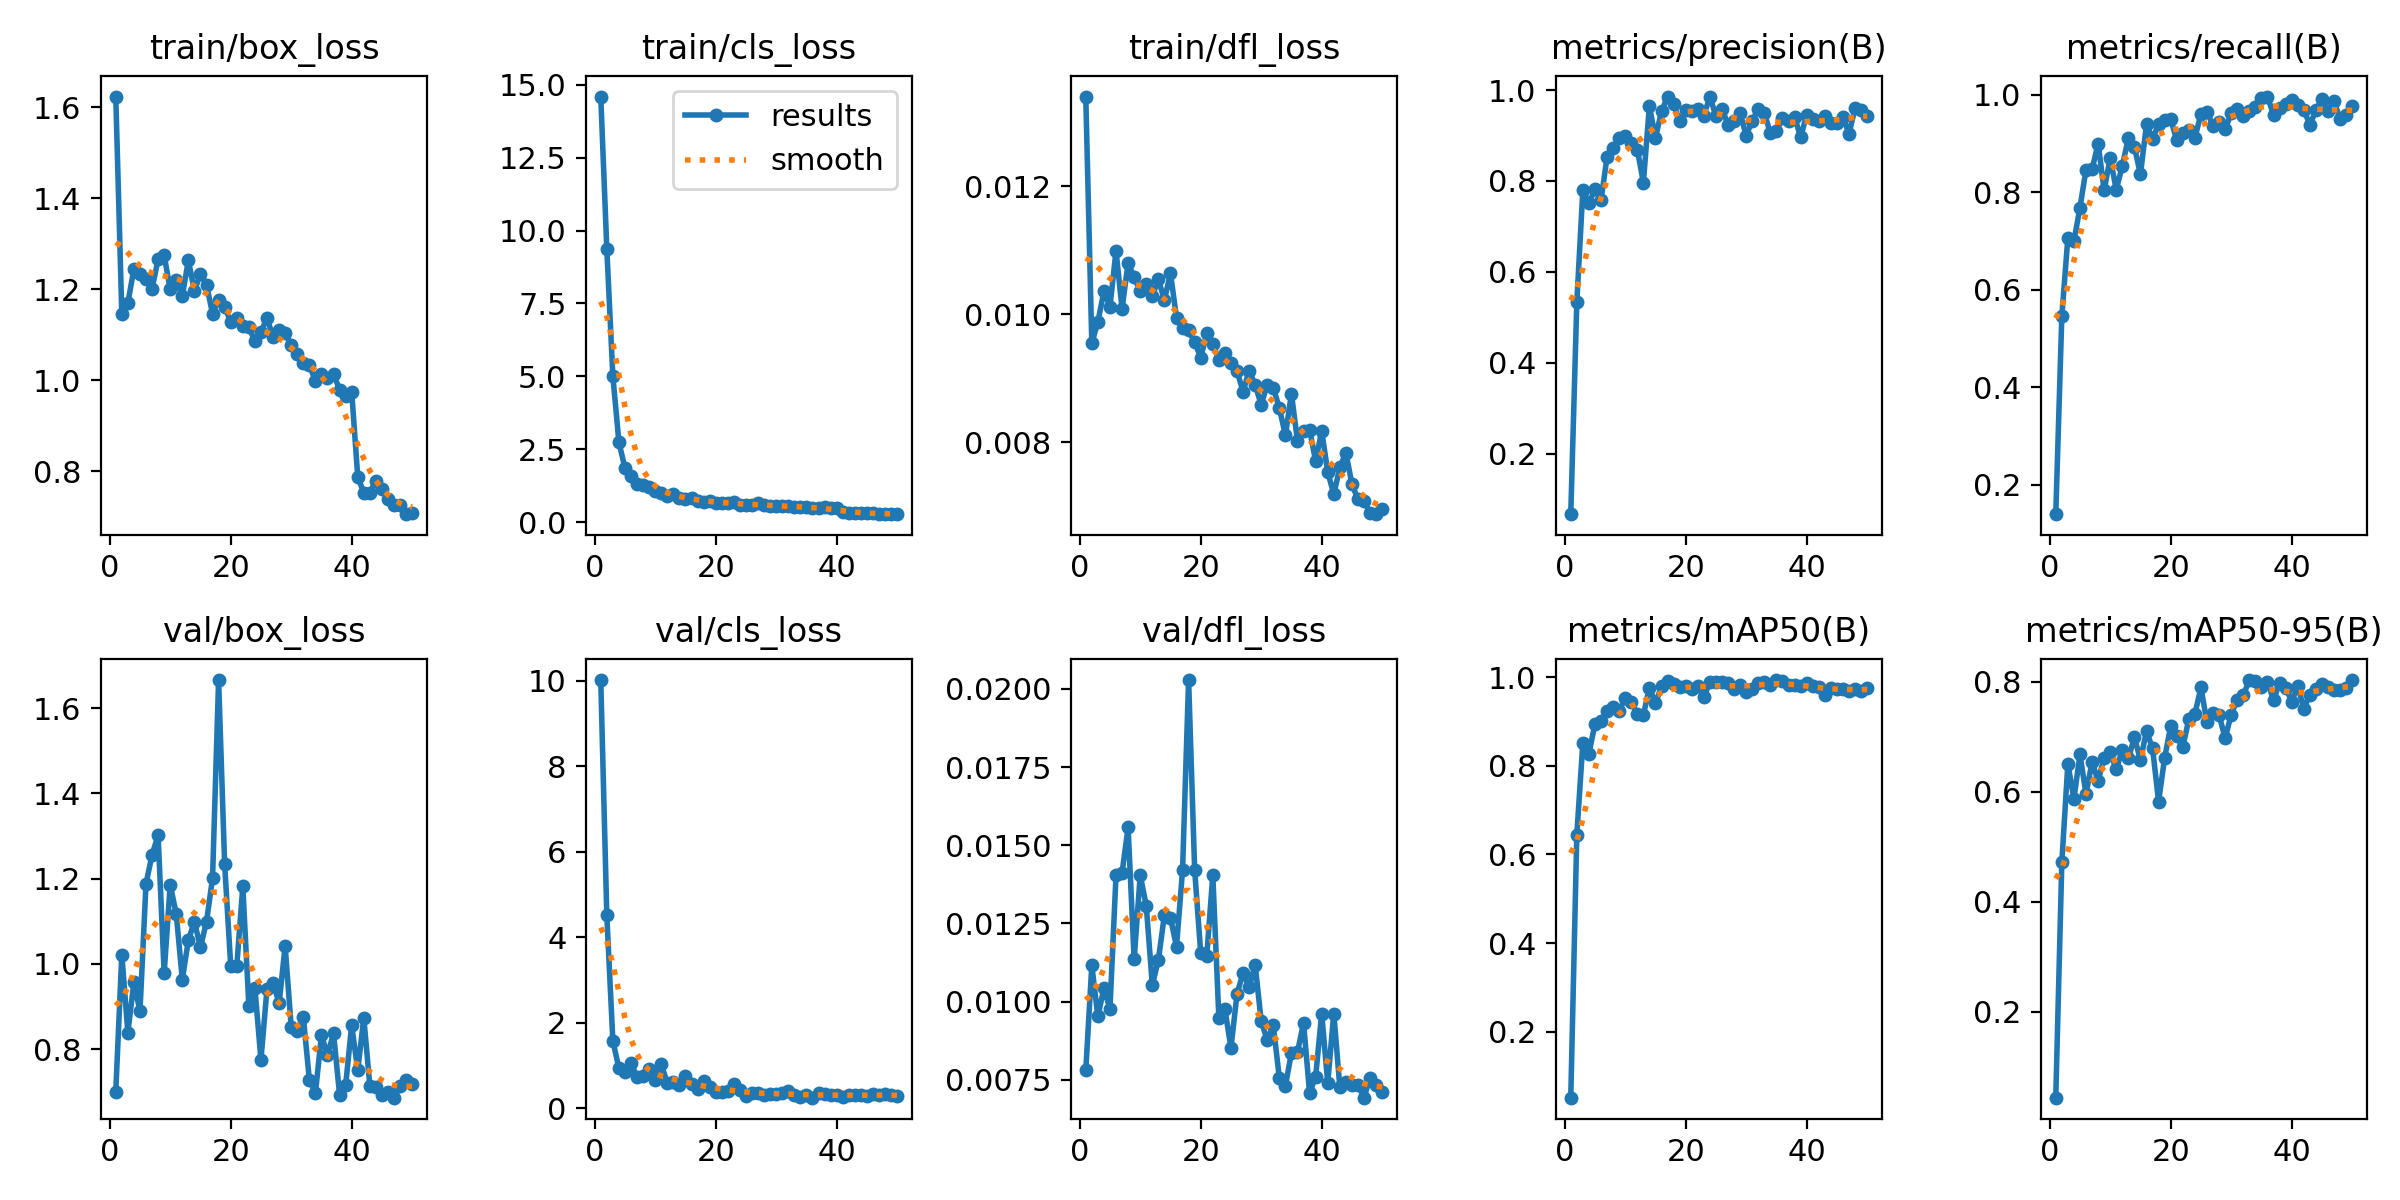


confusion_matrix.png:


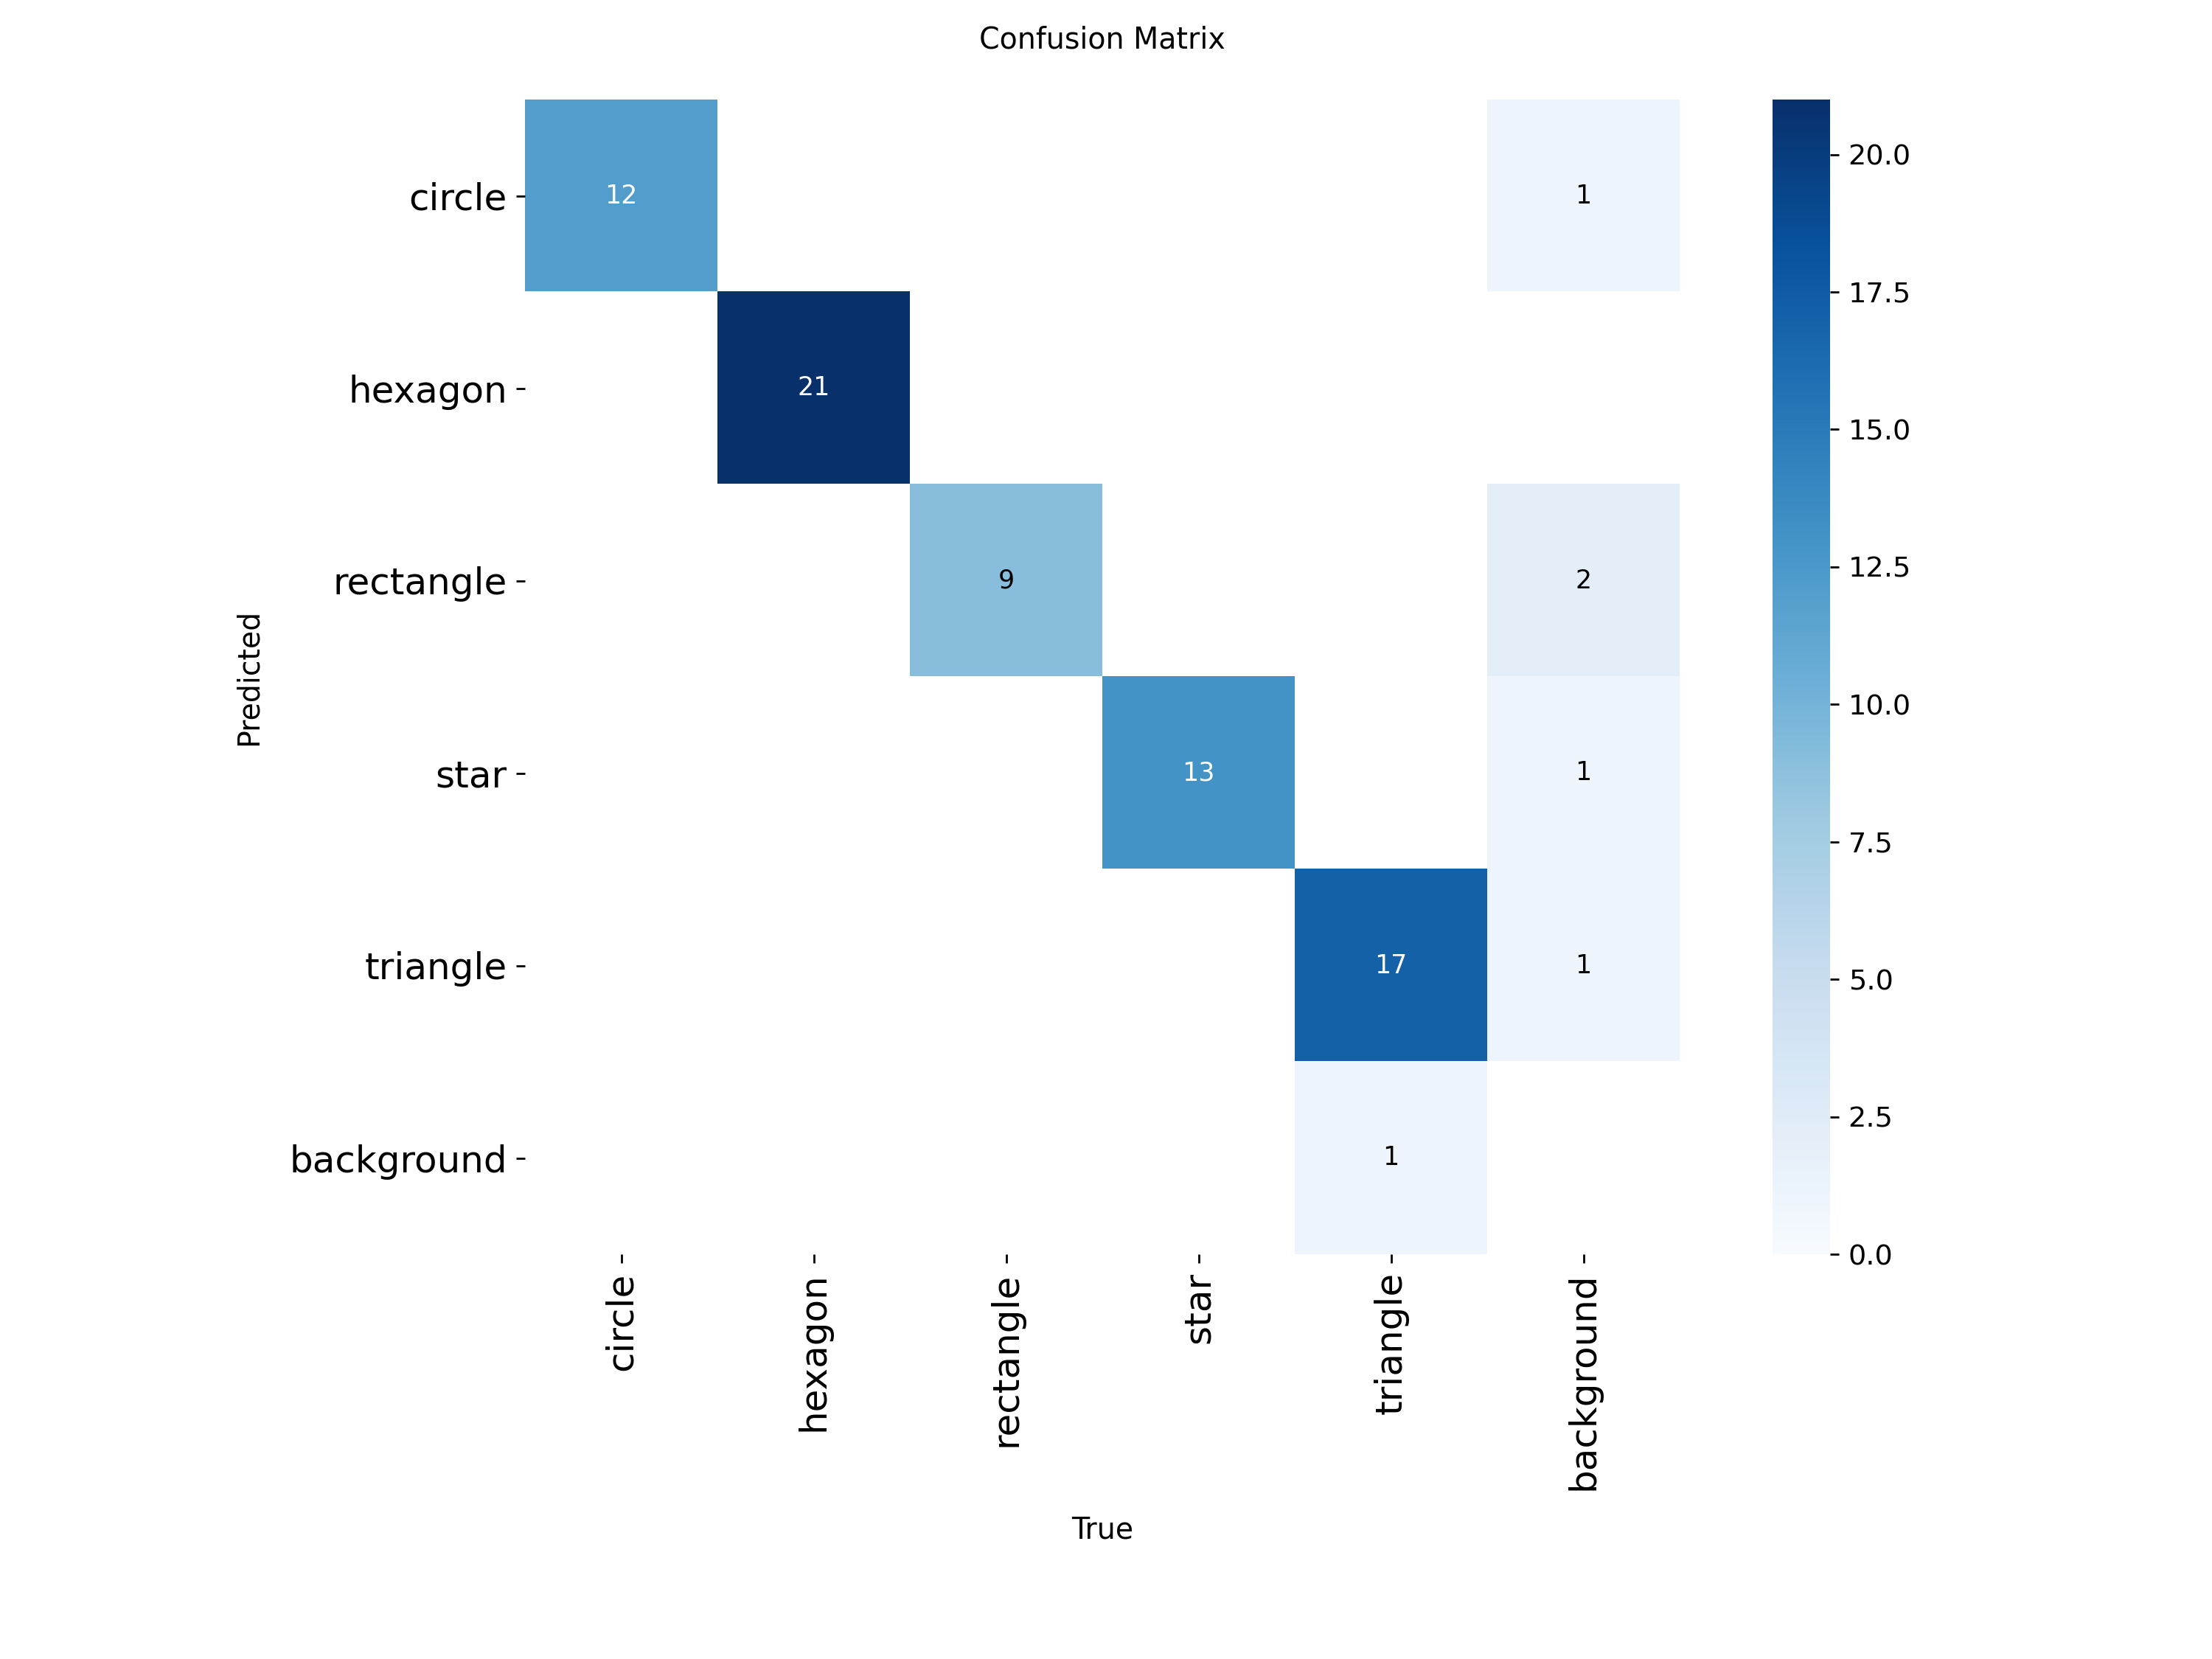


confusion_matrix_normalized.png:


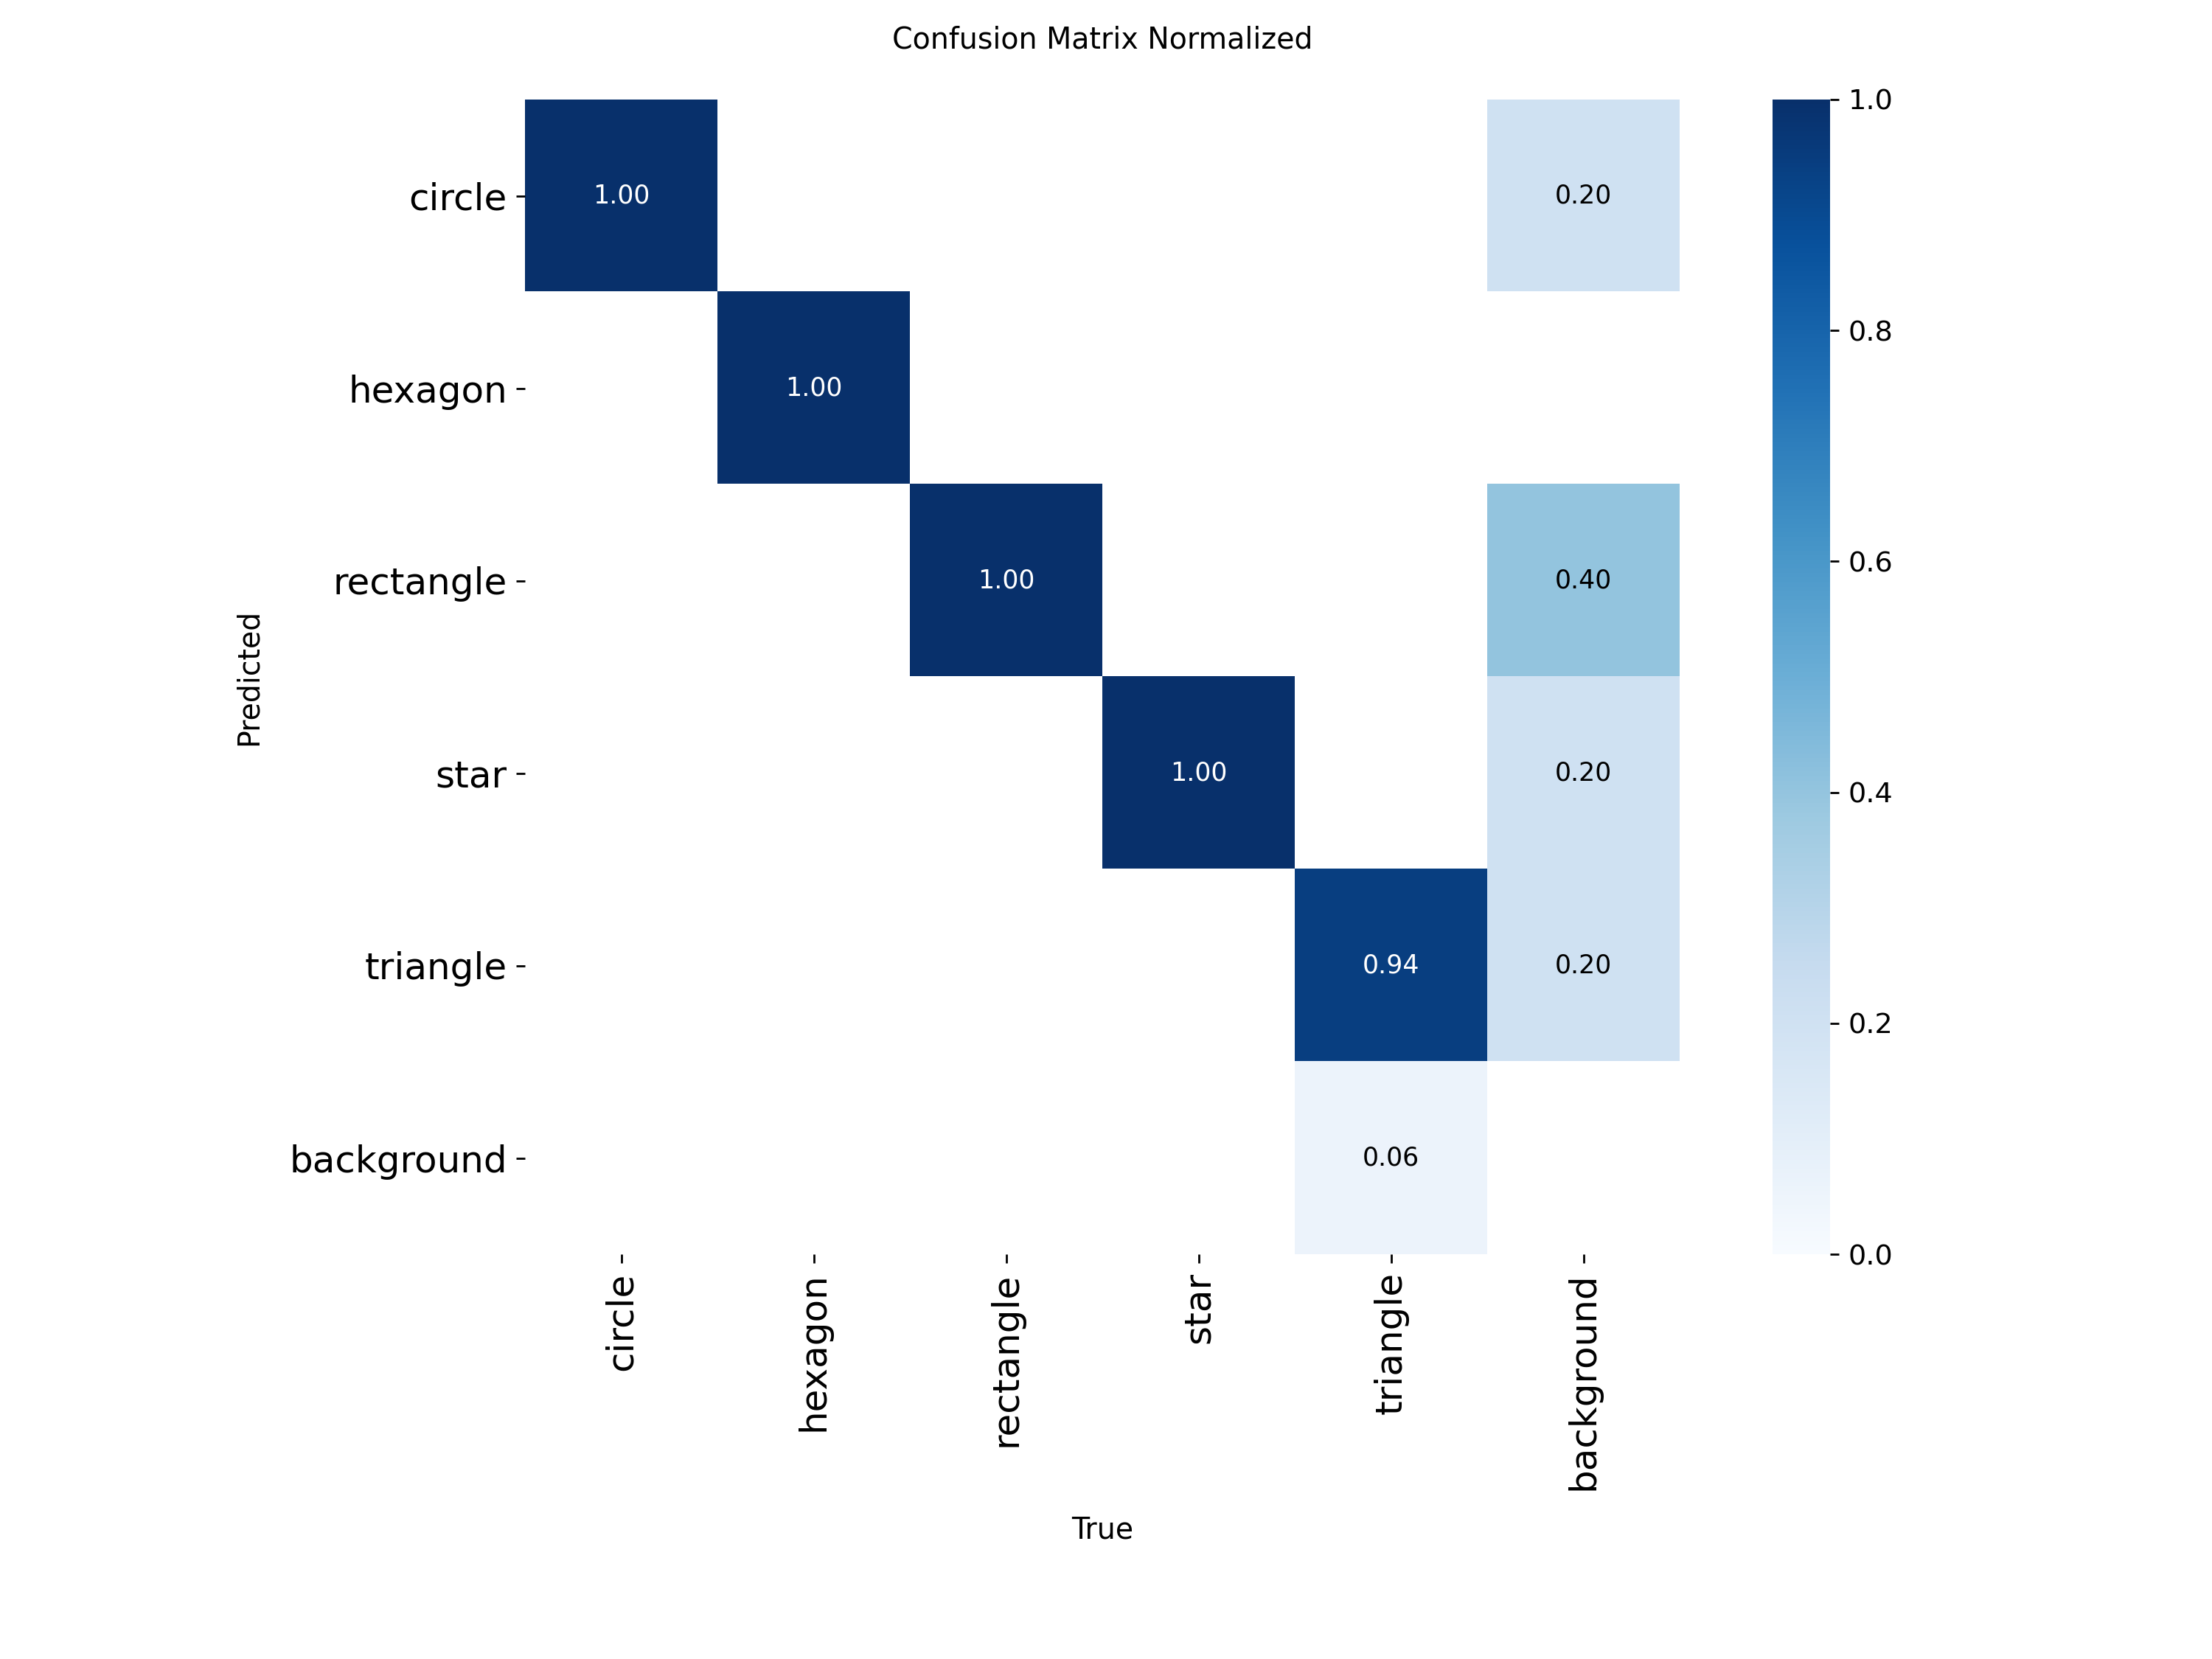

In [16]:
# Display training curves (saved by ultralytics during training)
from IPython.display import Image as IPImage, display

results_dir = Path(PROJECT) / EXPERIMENT

for plot_name in ["results.png", "confusion_matrix.png", "confusion_matrix_normalized.png"]:
    plot_path = results_dir / plot_name
    if plot_path.exists():
        print(f"\n{plot_name}:")
        display(IPImage(filename=str(plot_path)))

## 6. Export

In [17]:
# Summary of all saved artifacts
print("Training artifacts:")
results_dir = Path(PROJECT) / EXPERIMENT
for p in sorted(results_dir.rglob("*")):
    if p.is_file():
        size_mb = p.stat().st_size / 1024 / 1024
        print(f"  {p.relative_to(results_dir)}  ({size_mb:.1f} MB)")

Training artifacts:
  args.yaml  (0.0 MB)
  BoxF1_curve.png  (0.2 MB)
  BoxP_curve.png  (0.1 MB)
  BoxPR_curve.png  (0.1 MB)
  BoxR_curve.png  (0.2 MB)
  confusion_matrix.png  (0.1 MB)
  confusion_matrix_normalized.png  (0.1 MB)
  labels.jpg  (0.1 MB)
  results.csv  (0.0 MB)
  results.png  (0.2 MB)
  train_batch0.jpg  (0.3 MB)
  train_batch1.jpg  (0.3 MB)
  train_batch2.jpg  (0.3 MB)
  train_batch480.jpg  (0.2 MB)
  train_batch481.jpg  (0.3 MB)
  train_batch482.jpg  (0.2 MB)
  val_batch0_labels.jpg  (0.2 MB)
  val_batch0_pred.jpg  (0.2 MB)
  val_batch1_labels.jpg  (0.2 MB)
  val_batch1_pred.jpg  (0.2 MB)
  weights\best.pt  (19.4 MB)
  weights\last.pt  (19.4 MB)
